In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

# Cleaning 

In [6]:
path = 'src/aaa_fl_metros_wayback_2022_2025.csv'
df_gas = pd.read_csv(path)
df_gas[['regular','mid','premium']] = (
    df_gas[['regular','mid','premium']].round(3))


In [7]:
df_gas = df_gas.drop(columns = 'wayback_timestamp')

In [8]:
df_gas = df_gas.drop_duplicates()
df_gas

,date,metro,label,regular,mid,premium,diesel
0,2022-01-28,Bradenton-Sarasota-Venice,Current Avg.,3.351,3.731,4.006,3.716
1,2022-01-28,Bradenton-Sarasota-Venice,Yesterday Avg.,3.348,3.709,4.003,3.711
2,2022-01-28,Bradenton-Sarasota-Venice,Week Ago Avg.,3.236,3.625,3.915,3.563
3,2022-01-28,Bradenton-Sarasota-Venice,Month Ago Avg.,3.213,3.602,3.899,3.478
4,2022-01-28,Bradenton-Sarasota-Venice,Year Ago Avg.,2.366,2.726,3.014,2.617
...,...,...,...,...,...,...,...
57715,2025-12-30,The Villages,Current Avg.,2.801,3.267,3.590,3.474
57716,2025-12-30,The Villages,Yesterday Avg.,2.683,3.033,3.422,3.509
57717,2025-12-30,The Villages,Week Ago Avg.,2.808,3.231,3.555,3.540
57718,2025-12-30,The Villages,Month Ago Avg.,2.975,3.384,3.725,3.741


In [9]:
df_gas.loc[2]

date                      2022-01-28
metro      Bradenton-Sarasota-Venice
label                  Week Ago Avg.
regular                        3.236
mid                            3.625
premium                        3.915
diesel                         3.563
Name: 2, dtype: object

In [10]:
df_gas['date'] = pd.to_datetime(df_gas['date'])
df_gas['date'].dtype

dtype('<M8[us]')

In [11]:
df_gas = df_gas.sort_values(['metro', 'date'])
df_gas.head()

,date,metro,label,regular,mid,premium,diesel
0,2022-01-28,Bradenton-Sarasota-Venice,Current Avg.,3.351,3.731,4.006,3.716
1,2022-01-28,Bradenton-Sarasota-Venice,Yesterday Avg.,3.348,3.709,4.003,3.711
2,2022-01-28,Bradenton-Sarasota-Venice,Week Ago Avg.,3.236,3.625,3.915,3.563
3,2022-01-28,Bradenton-Sarasota-Venice,Month Ago Avg.,3.213,3.602,3.899,3.478
4,2022-01-28,Bradenton-Sarasota-Venice,Year Ago Avg.,2.366,2.726,3.014,2.617


# Dates

In [12]:
#Change date of "yesterday avg." and "week ago avg.". remove month ago avg.

mask = df_gas['label'] =='Yesterday Avg.'
df_gas.loc[mask, 'date'] = df_gas.loc[mask,'date'] - timedelta(days=1)

mask2 = df_gas['label'] == 'Week Ago Avg.'
df_gas.loc[mask2, 'date'] = df_gas.loc[mask2, 'date'] - timedelta(days=7)

mask3 = (df_gas['label'] == 'Month Ago Avg.') | (df_gas['label'] == 'Year Ago Avg.')
df_gas = df_gas.loc[~mask3]

df_gas

,date,metro,label,regular,mid,premium,diesel
0,2022-01-28,Bradenton-Sarasota-Venice,Current Avg.,3.351,3.731,4.006,3.716
1,2022-01-27,Bradenton-Sarasota-Venice,Yesterday Avg.,3.348,3.709,4.003,3.711
2,2022-01-21,Bradenton-Sarasota-Venice,Week Ago Avg.,3.236,3.625,3.915,3.563
120,2022-03-07,Bradenton-Sarasota-Venice,Current Avg.,4.005,4.292,4.603,4.559
121,2022-03-06,Bradenton-Sarasota-Venice,Yesterday Avg.,3.950,4.228,4.525,4.526
...,...,...,...,...,...,...,...
57531,2025-12-28,West Palm Beach-Boca Raton,Yesterday Avg.,2.912,3.333,3.692,3.626
57532,2025-12-22,West Palm Beach-Boca Raton,Week Ago Avg.,3.027,3.486,3.822,3.627
57650,2025-12-30,West Palm Beach-Boca Raton,Current Avg.,2.954,3.405,3.757,3.610
57651,2025-12-29,West Palm Beach-Boca Raton,Yesterday Avg.,2.901,3.304,3.679,3.615


In [13]:
df_gas = df_gas.drop(columns = ['label'])
df_gas.head()

,date,metro,regular,mid,premium,diesel
0,2022-01-28,Bradenton-Sarasota-Venice,3.351,3.731,4.006,3.716
1,2022-01-27,Bradenton-Sarasota-Venice,3.348,3.709,4.003,3.711
2,2022-01-21,Bradenton-Sarasota-Venice,3.236,3.625,3.915,3.563
120,2022-03-07,Bradenton-Sarasota-Venice,4.005,4.292,4.603,4.559
121,2022-03-06,Bradenton-Sarasota-Venice,3.950,4.228,4.525,4.526


In [14]:

df_gas = df_gas.sort_values(['metro', 'date'])
df_gas = df_gas.drop_duplicates()

df_gas

,date,metro,regular,mid,premium,diesel
2,2022-01-21,Bradenton-Sarasota-Venice,3.236,3.625,3.915,3.563
1,2022-01-27,Bradenton-Sarasota-Venice,3.348,3.709,4.003,3.711
0,2022-01-28,Bradenton-Sarasota-Venice,3.351,3.731,4.006,3.716
122,2022-02-28,Bradenton-Sarasota-Venice,3.502,3.862,4.164,3.933
242,2022-03-01,Bradenton-Sarasota-Venice,3.502,3.862,4.164,3.933
...,...,...,...,...,...,...
57411,2025-12-26,West Palm Beach-Boca Raton,2.930,3.387,3.719,3.626
57410,2025-12-27,West Palm Beach-Boca Raton,2.917,3.350,3.682,3.626
57531,2025-12-28,West Palm Beach-Boca Raton,2.912,3.333,3.692,3.626
57530,2025-12-29,West Palm Beach-Boca Raton,2.901,3.304,3.679,3.615


<Axes: xlabel='date'>

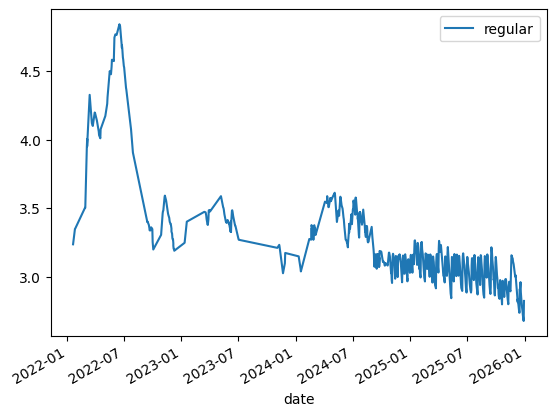

In [15]:
df_BSV = df_gas[df_gas['metro']=='Bradenton-Sarasota-Venice']
df_BSV.plot(x='date', y = 'regular')

In [16]:
#interpolate 

df_daily = (df_gas
            .set_index('date')
            .groupby('metro')
            .resample('D')
            .mean()
            .interpolate('linear')
           .reset_index())

In [18]:
df_daily = df_daily.sort_values(['metro', 'date'])

df_daily['reg_delt'] = (
    df_daily
    .groupby('metro')['regular']
    .pct_change() * 100
)

df_daily.head()

,metro,date,regular,mid,premium,diesel,reg_delt
0,Bradenton-Sarasota-Venice,2022-01-21,3.236000,3.625,3.915000,3.563000,NaN
1,Bradenton-Sarasota-Venice,2022-01-22,3.254667,3.639,3.929667,3.587667,0.576844
2,Bradenton-Sarasota-Venice,2022-01-23,3.273333,3.653,3.944333,3.612333,0.573535
3,Bradenton-Sarasota-Venice,2022-01-24,3.292000,3.667,3.959000,3.637000,0.570265
4,Bradenton-Sarasota-Venice,2022-01-25,3.310667,3.681,3.973667,3.661667,0.567031


# Integration with coordinates

https://simplemaps.com/data/us-metros

In [19]:
path = 'Data/usmetros.csv'
df_geo = pd.read_csv(path)
df_geo.columns = df_geo.columns.str.lower()

df_fl_coor = df_geo[df_geo["state_id"] == "FL"]

df_fl_coor["metro_full"]= df_fl_coor["metro_full"].astype(str)
df_fl_coor["metro_full"].dtype
df_fl_coor[["met", "state"]] = df_fl_coor["metro_full"].str.split(",", expand = True)

`df_gas["metro]` and `df_fl_coor["met"]` 

In [20]:
map = {
    "Bradenton-Sarasota-Venice" : "North Port-Bradenton-Sarasota",
    "Daytona Beach" : "Deltona-Daytona Beach-Ormond Beach",
    "Fort Myers-Cape Coral" : "Cape Coral-Fort Myers",
    "Homosassa Springs": "Homosassa Springs",
    "West Palm Beach-Boca Raton":"Miami-Fort Lauderdale-West Palm Beach",
    "Miami" : "Miami-Fort Lauderdale-West Palm Beach",
    "Fort Lauderdale" : "Miami-Fort Lauderdale-West Palm Beach",
    "Ocala" : "Ocala",
    "Panama City" :  "Panama City-Panama City Beach",
    "Port St. Lucie" : "Port St. Lucie",
    "Sebastian-Vero Beach" : "Sebastian-Vero Beach-West Vero Corridor",
    "Tallahassee": "Tallahassee",
    "The Villages" : "Wildwood-The Villages",
    "Crestview-Fort Walton Beach" : "Crestview-Fort Walton Beach-Destin",
    "Gainesville" : "Gainesville",
    "Jacksonville" : "Jacksonville",
    "Melbourne-Titusville" : "Palm Bay-Melbourne-Titusville",
    "Naples" : "Naples-Marco Island",
    "Orlando" : "Orlando-Kissimmee-Sanford",
    "Pensacola" : "Pensacola-Ferry Pass-Brent",
    "Sebring" : "Sebring",
    "Tampa" : "Tampa-St. Petersburg-Clearwater",
}


In [21]:
df_daily["met"] = df_daily["metro"].astype(str).str.strip()
df_daily["met"] = df_daily["metro"].map(map).fillna(df_daily["metro"])

df_daily["met"] = df_daily["met"].astype(str).str.strip()
df_fl_coor["met"] = df_fl_coor["met"].astype(str).str.strip()

In [22]:
df_gas_coor = df_daily.merge(
    df_fl_coor[["met", "lat", "lng"]],
    on = "met",
    how = "left"
)

In [23]:
df_gas_coor.head()

,metro,date,regular,mid,premium,diesel,reg_delt,met,lat,lng
0,Bradenton-Sarasota-Venice,2022-01-21,3.236000,3.625,3.915000,3.563000,NaN,North Port-Bradenton-Sarasota,27.3479,-82.3223
1,Bradenton-Sarasota-Venice,2022-01-22,3.254667,3.639,3.929667,3.587667,0.576844,North Port-Bradenton-Sarasota,27.3479,-82.3223
2,Bradenton-Sarasota-Venice,2022-01-23,3.273333,3.653,3.944333,3.612333,0.573535,North Port-Bradenton-Sarasota,27.3479,-82.3223
3,Bradenton-Sarasota-Venice,2022-01-24,3.292000,3.667,3.959000,3.637000,0.570265,North Port-Bradenton-Sarasota,27.3479,-82.3223
4,Bradenton-Sarasota-Venice,2022-01-25,3.310667,3.681,3.973667,3.661667,0.567031,North Port-Bradenton-Sarasota,27.3479,-82.3223


In [25]:
df_gas_coor.to_csv("data/gas_days_geo.csv", index=False)

In [24]:
df_gas_coor.isna().sum()

metro        0
date         0
regular      0
mid          0
premium      0
diesel       0
reg_delt    24
met          0
lat          0
lng          0
dtype: int64

scrap

| `df_gas["metro]`| `df_fl_coor["met"]` | Match? |
| :--- | :--- | :---: | 
| Bradenton-Sarasota-Venice | North Port-Bradenton-Sarasota | No |
| Daytona Beach | Deltona-Daytona Beach-Ormond Beach | No |
| Fort Myers-Cape Coral | Cape Coral-Fort Myers | No |
| Homosassa Springs | Homosassa Springs | Yes |
| Miami | Miami-Fort Lauderdale-West Palm Beach | No |
| Fort Lauderdale | Miami-Fort Lauderdale-West Palm Beach | No |
| Ocala | Ocala | Yes |
| Panama City | Panama City-Panama City Beach | No |
| Port St. Lucie | Port St. Lucie | Yes |
| Sebastian-Vero Beach | Sebastian-Vero Beach-West Vero Corridor | No |
| Tallahassee | Tallahassee | Yes |
| The Villages | Wildwood-The Villages | No |
| Crestview-Fort Walton Beach | Crestview-Fort Walton Beach-Destin | No |
| Gainesville | Gainesville | Yes |
| Jacksonville | Jacksonville | Yes |
| Melbourne-Titusville | --- | No |
| Naples | Naples-Marco Island | No |
| Orlando | Orlando-Kissimmee-Sanford | No |
| Pensacola | Pensacola | Yes |
| Punta Gorda | Punta Gorda | Yes |
| Sebring| Sebring | Yes |
| Tampa-St. Petersburg-Clearwater | Tampa | No |

### Name mapping 

Matching names between `geographic df` and `gas df`

1. Split df_fl_coor["metro_full"] to parse FL out
2. Mapped names from `df_gas["metro]` and `df_fl_coor["met"]` 